/tmp/ipykernel_694/820213357.py:10: DtypeWarning: Columns (0,11,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


  Row ID         Order ID  Order Date   Ship Date     Ship Mode Customer ID  \
0  32298   CA-2012-124891  31-07-2012  31-07-2012      Same Day    RH-19495   
1  26341    IN-2013-77878  05-02-2013  07-02-2013  Second Class    JR-16210   
2  25330    IN-2013-71249  17-10-2013  18-10-2013   First Class    CR-12730   
3  13524  ES-2013-1579342  28-01-2013  30-01-2013   First Class    KM-16375   
4  47221     SG-2013-4320  05-11-2013  06-11-2013      Same Day     RH-9495   

      Customer Name      Segment           City            State  ...  \
0       Rick Hansen     Consumer  New York City         New York  ...   
1     Justin Ritter    Corporate     Wollongong  New South Wales  ...   
2      Craig Reiter     Consumer       Brisbane       Queensland  ...   
3  Katherine Murray  Home Office         Berlin           Berlin  ...   
4       Rick Hansen     Consumer          Dakar            Dakar  ...   

         Product ID    Category Sub-Category  \
0   TEC-AC-10003033  Technology  Acces

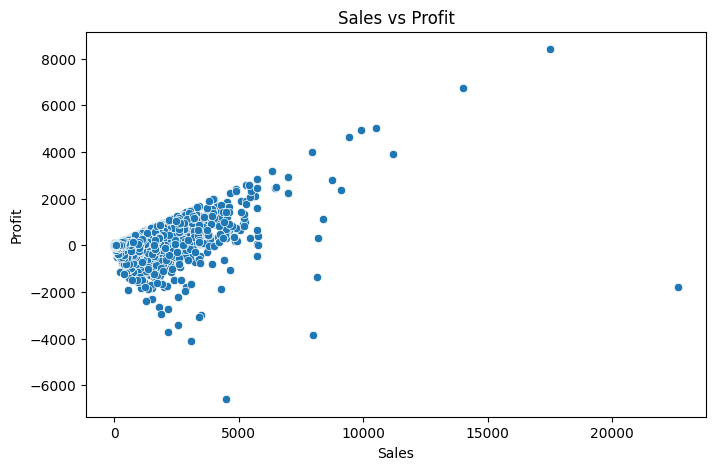

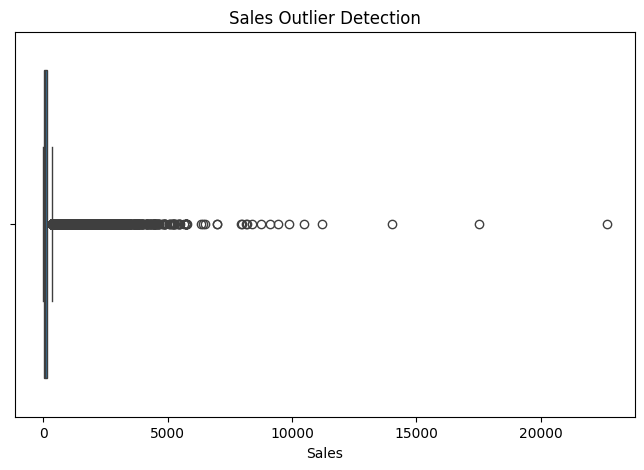

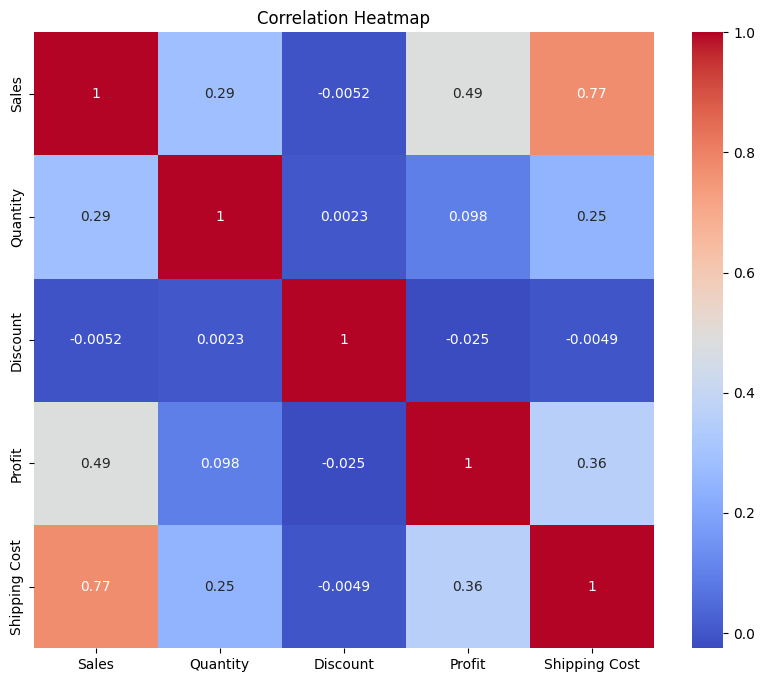

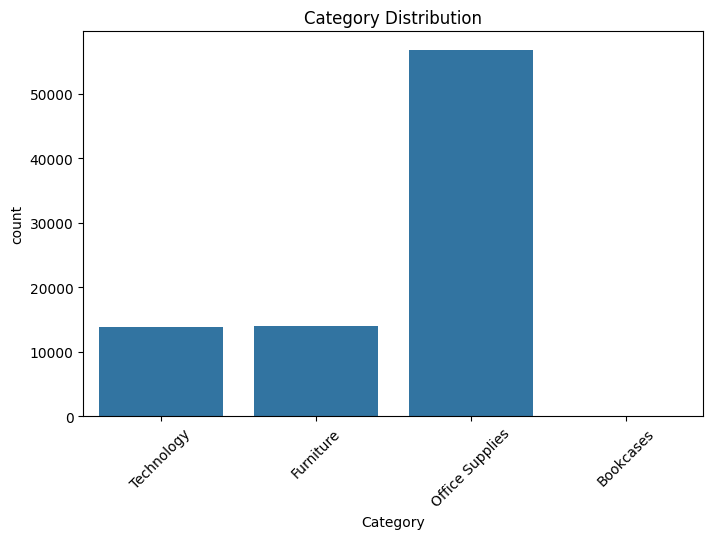

/tmp/ipykernel_694/820213357.py:113: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(


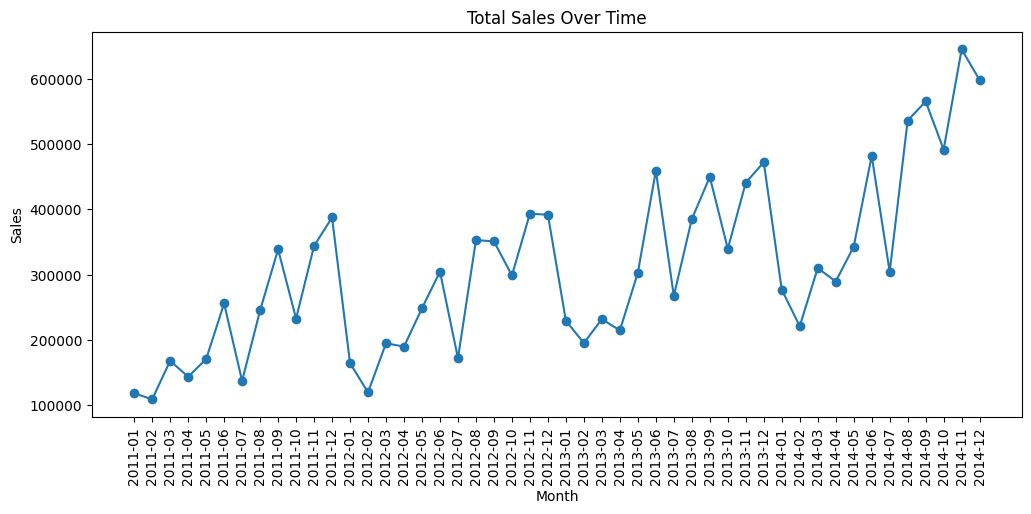

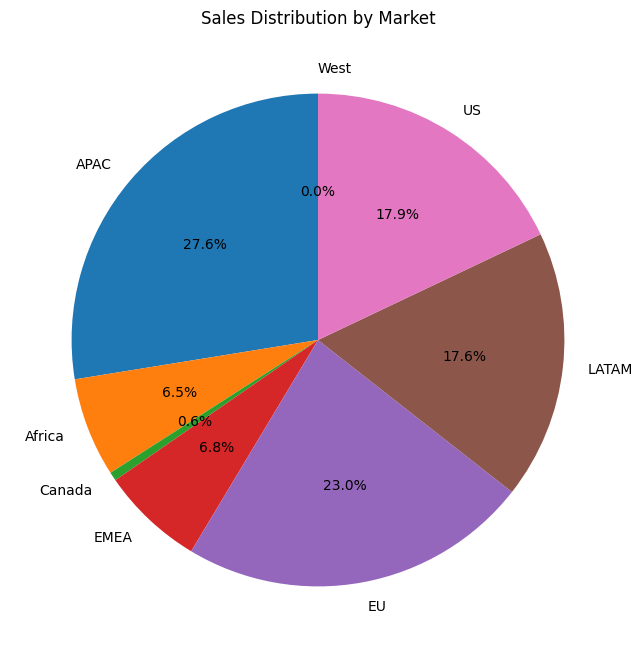

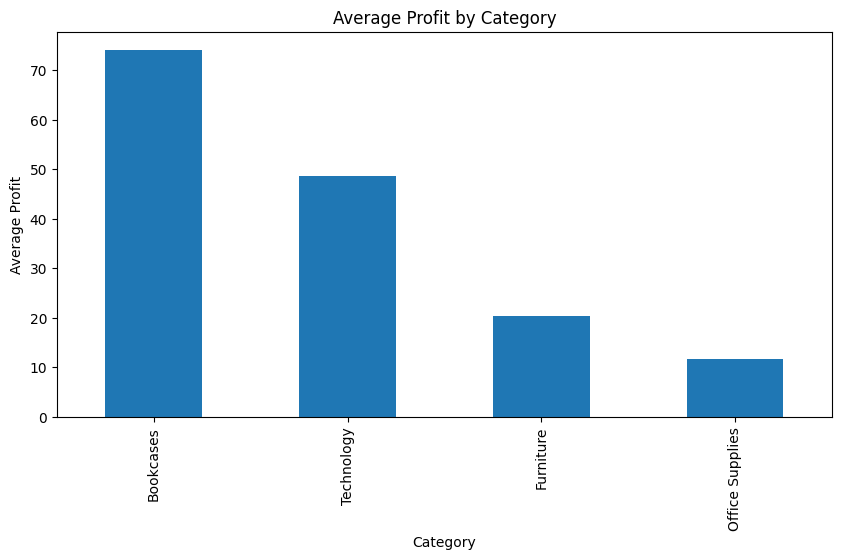

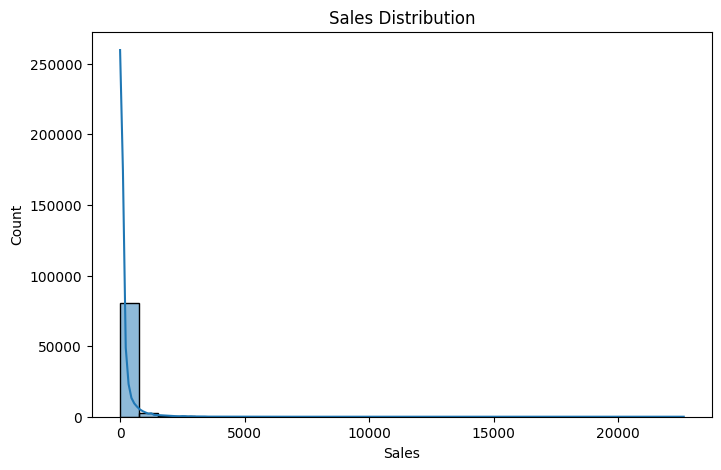

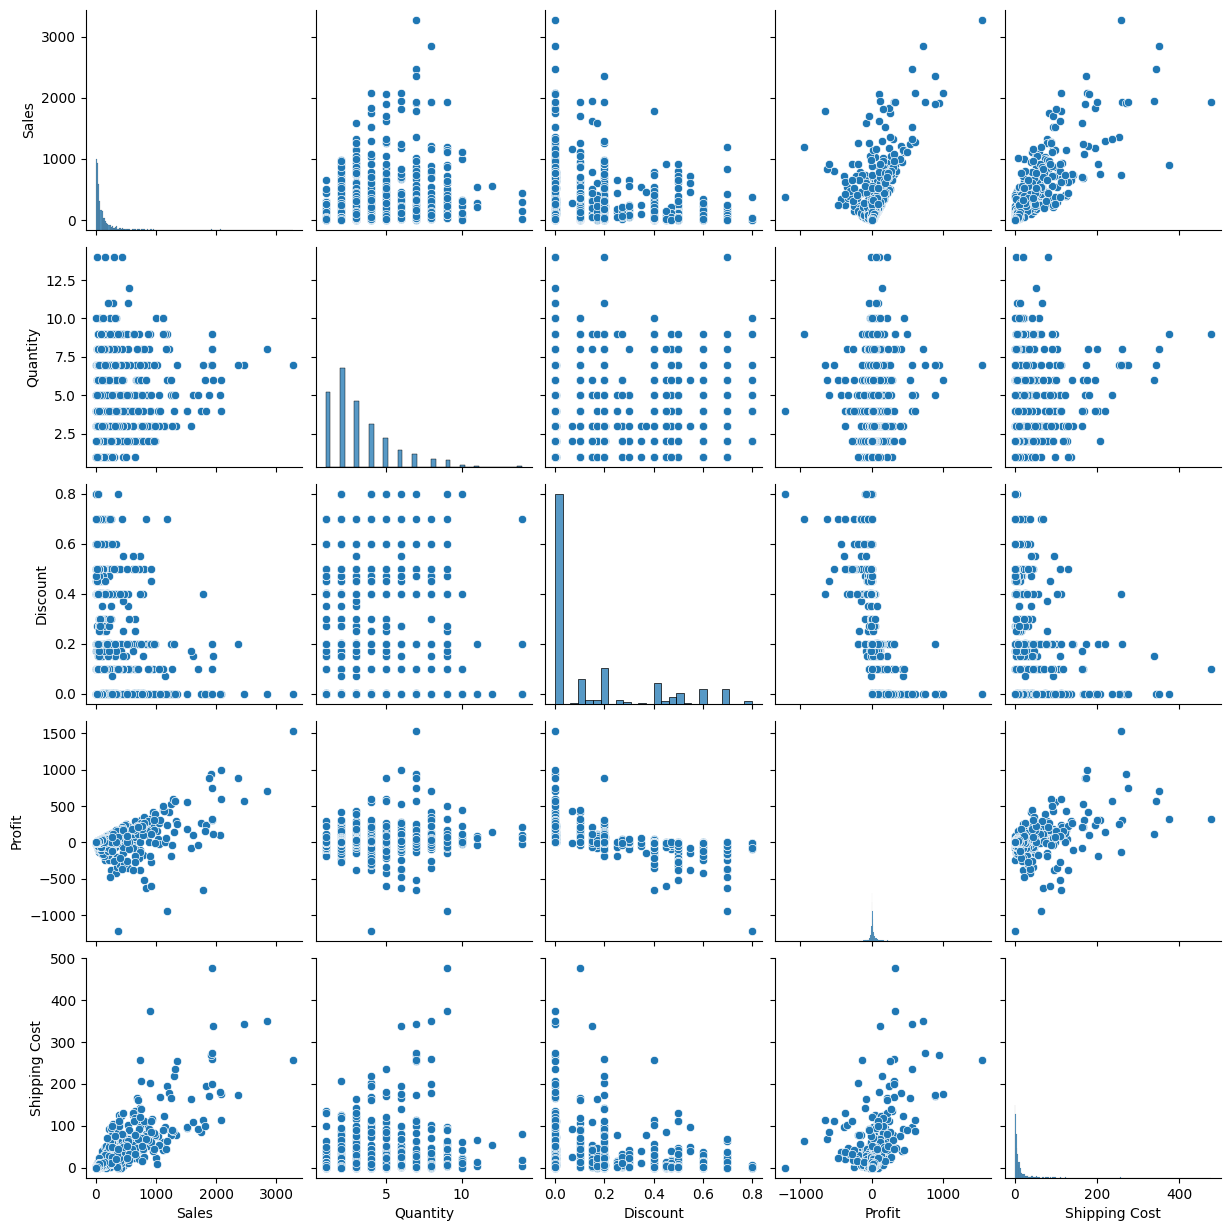

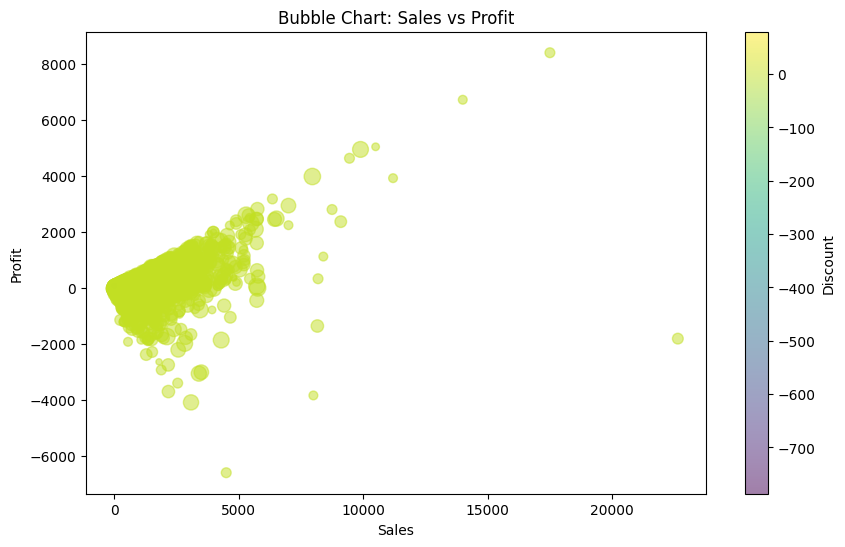

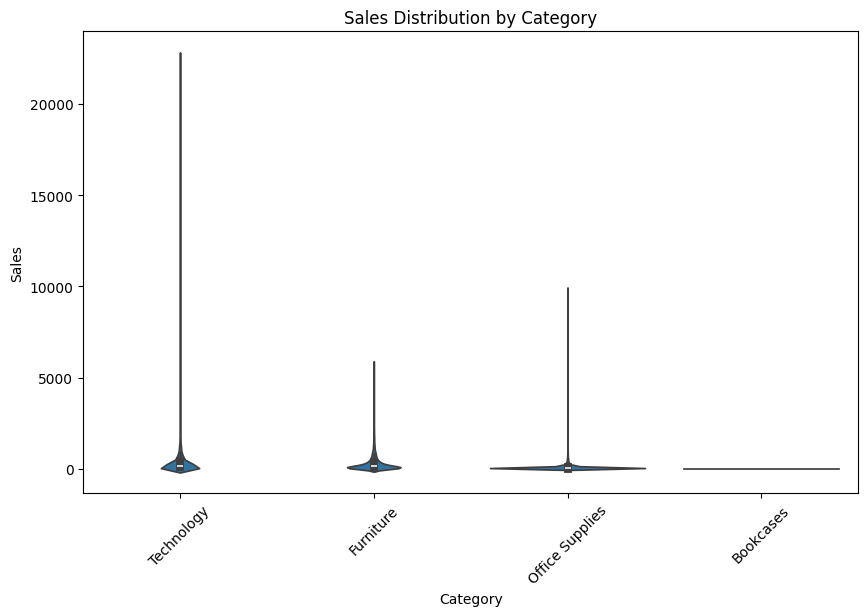

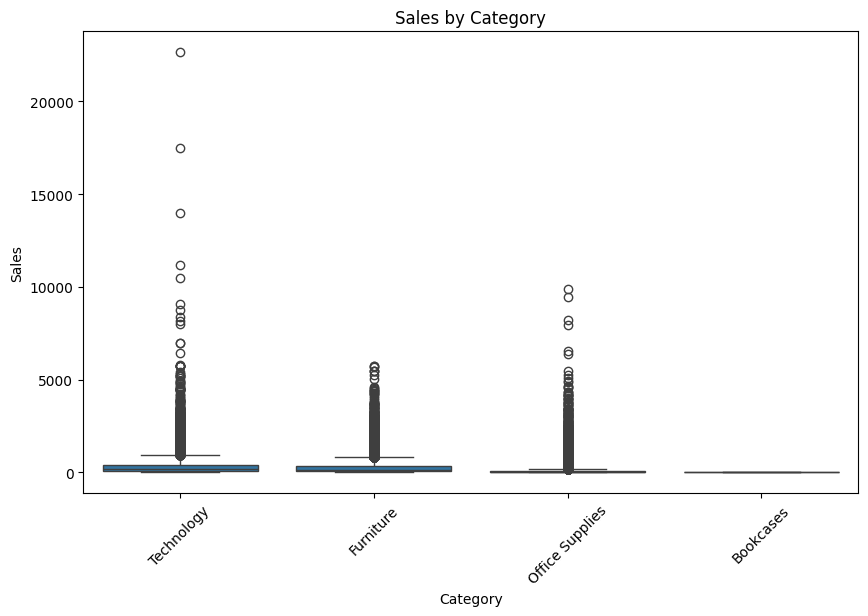

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================
# 1. Load Dataset
# ==========================================

df = pd.read_csv(
    "Global_Superstore2.csv",
    encoding="latin1",
    sep=',',
    quotechar='"',
    on_bad_lines='skip'
)

print(df.head())


# ==========================================
# 2. Scatter Plot - Sales vs Profit
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()


# ==========================================
# 3. Boxplot - Sales Outlier Detection
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Outlier Detection")
plt.xlabel("Sales")

plt.show()


# ==========================================
# 4. Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))

# Convert 'Shipping Cost' to numeric, coercing errors to NaN
# Added .astype(str).str.strip() for robust cleaning
df['Shipping Cost'] = df['Shipping Cost'].astype(str).str.strip()
df['Shipping Cost'] = pd.to_numeric(df['Shipping Cost'], errors='coerce')

# Fill NaN values with the median of 'Shipping Cost'
df['Shipping Cost'] = df['Shipping Cost'].fillna(df['Shipping Cost'].median())

corr = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Profit",
        "Shipping Cost"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


# ==========================================
# 5. Category Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Category"
)

plt.xticks(rotation=45)

plt.title("Category Distribution")

plt.show()


# ==========================================
# 6. Sales Over Time
# ==========================================

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

monthly_sales = (
    df.groupby(
        df["Order Date"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales,
    marker="o"
)

plt.title("Total Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()


# ==========================================
# 7. Sales Distribution by Market
# ==========================================

market_sales = df.groupby("Market")["Sales"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    market_sales,
    labels=market_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Market")

plt.show()


# ==========================================
# 8. Average Profit by Category
# ==========================================

category_profit = df.groupby("Category")["Profit"].mean()

category_profit = category_profit.sort_values(
    ascending=False
)

plt.figure(figsize=(10,5))

category_profit.plot(kind="bar")

plt.title("Average Profit by Category")
plt.xlabel("Category")
plt.ylabel("Average Profit")

plt.show()


# ==========================================
# 9. Sales Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=30,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")

plt.show()


# ==========================================
# 10. Pair Plot
# ==========================================

sns.pairplot(
    df[
        [
            "Sales",
            "Quantity",
            "Discount",
            "Profit",
            "Shipping Cost"
        ]
    ].dropna().sample(
        min(2000, len(df)),
        random_state=42
    )
)

plt.show()


# ==========================================
# 11. Bubble Chart
# ==========================================

plt.figure(figsize=(10,6))

plt.scatter(
    df["Sales"],
    df["Profit"],
    s=df["Quantity"] * 10,
    alpha=0.5,
    c=df["Discount"],
    cmap="viridis"
)

plt.colorbar(
    label="Discount"
)

plt.xlabel("Sales")
plt.ylabel("Profit")

plt.title("Bubble Chart: Sales vs Profit")

plt.show()


# ==========================================
# 12. Violin Plot
# ==========================================

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="Category",
    y="Sales"
)

plt.xticks(rotation=45)

plt.title("Sales Distribution by Category")

plt.show()


# ==========================================
# 13. Boxplot by Category
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Category",
    y="Sales"
)

plt.xticks(rotation=45)

plt.title("Sales by Category")

plt.show()